In [2]:
# Loading the Datasets (MY STEP 1)
import pandas as pd
df = pd.read_csv("Housing.csv")

In [3]:
# Understanding the Dataset (MY STEP 2)
print(df.head())
print(df.shape)
print(df.columns)
print(df.describe())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
(545, 13)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom

In [4]:
# Handling Missing Values (MY STEP 3)
print(df.isnull().sum())
print("Duplicate Rows: ", df.duplicated().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicate Rows:  0


In [5]:
# Filling Missing Values (MY STEP 4)

In [6]:
# (MY STEP 5)
print(df.dtypes)

# Get numeric columns (integers and floats)
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Get categorical columns (strings, objects, or category data types)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print the results
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
Numerical Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical Columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [7]:
# Confirming Missing Values (MY STEP 6)
print(df.isnull().sum())
print("Duplicate Rows: ", df.duplicated().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicate Rows:  0


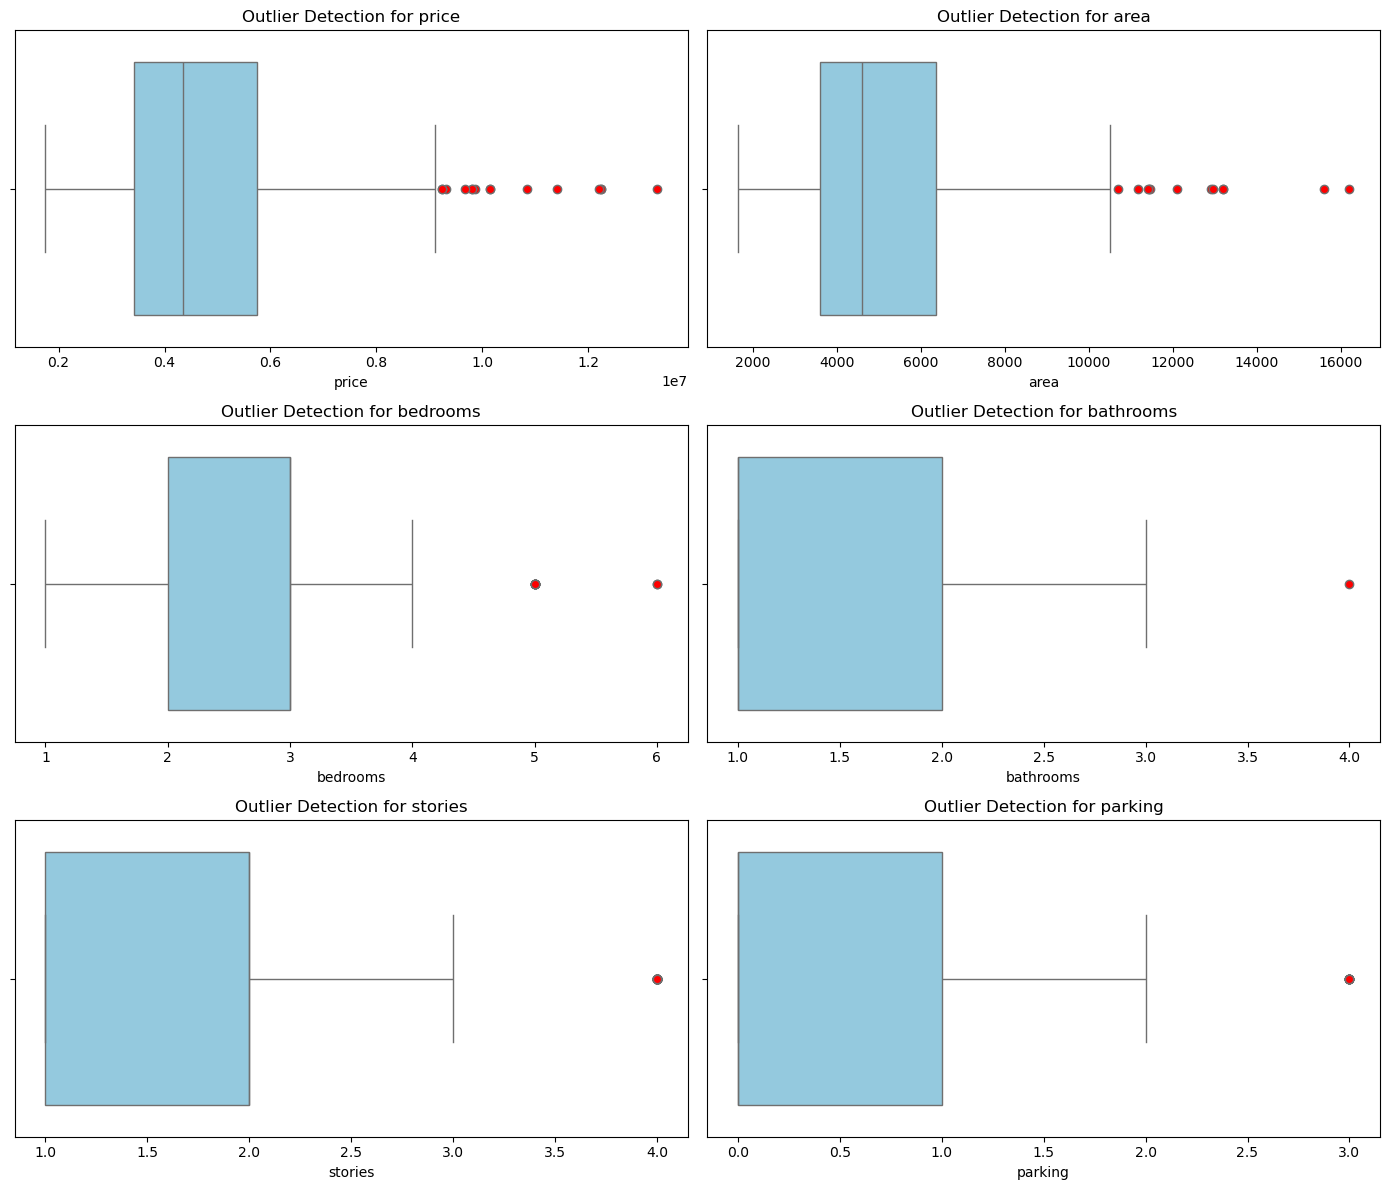

In [8]:
# Outlier Detection (My Step 7)
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Define your numerical columns (e.g., from your dataset)
# Replace these with your actual numeric column names
num_columns = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# 1. Automatically calculate grid size based on column count
num_plots = len(num_columns)
cols_per_row = 2
rows_needed = math.ceil(num_plots / cols_per_row)

# 2. Setup figure dimensions dynamically
plt.figure(figsize=(14, 4 * rows_needed))

for i, column in enumerate(num_columns, 1):
    plt.subplot(rows_needed, cols_per_row, i)

    # 3. Use Seaborn's boxplot to clearly show outliers as dots
    sns.boxplot(x=df[column], color="skyblue", flierprops={"markerfacecolor": "red", "marker": "o"})

    plt.xlabel(column)
    plt.title(f"Outlier Detection for {column}")

# Clean layout spacing so text elements don't overlap
plt.tight_layout()
plt.show()


In [10]:
# Calculate the IQR boundaries (My Step 8)

for column in num_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f'{column}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Lower Bound: {lower_bound}')
    print(f'Upper Bound: {upper_bound}')
    print('-' * 40)

price
Q1: 3430000.0
Q3: 5740000.0
IQR: 2310000.0
Lower Bound: -35000.0
Upper Bound: 9205000.0
----------------------------------------
area
Q1: 3600.0
Q3: 6360.0
IQR: 2760.0
Lower Bound: -540.0
Upper Bound: 10500.0
----------------------------------------
bedrooms
Q1: 2.0
Q3: 3.0
IQR: 1.0
Lower Bound: 0.5
Upper Bound: 4.5
----------------------------------------
bathrooms
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Bound: -0.5
Upper Bound: 3.5
----------------------------------------
stories
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Bound: -0.5
Upper Bound: 3.5
----------------------------------------
parking
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
----------------------------------------


In [11]:
# My Step 9

numeric_columns = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} potential outliers")

price: 15 potential outliers
area: 12 potential outliers
bedrooms: 12 potential outliers
bathrooms: 1 potential outliers
stories: 41 potential outliers
parking: 12 potential outliers


In [12]:
# My Step 10

for column in numeric_columns:
    print(f"\n{column}")
    print(df[column].value_counts().sort_index())


price
price
1750000     3
1767150     1
1820000     1
1855000     1
1890000     2
           ..
10850000    1
11410000    1
12215000    1
12250000    2
13300000    1
Name: count, Length: 219, dtype: int64

area
area
1650     1
1700     1
1836     1
1905     1
1950     2
        ..
12900    1
12944    1
13200    2
15600    1
16200    1
Name: count, Length: 284, dtype: int64

bedrooms
bedrooms
1      2
2    136
3    300
4     95
5     10
6      2
Name: count, dtype: int64

bathrooms
bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

stories
stories
1    227
2    238
3     39
4     41
Name: count, dtype: int64

parking
parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64


In [13]:
# My Step 11

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


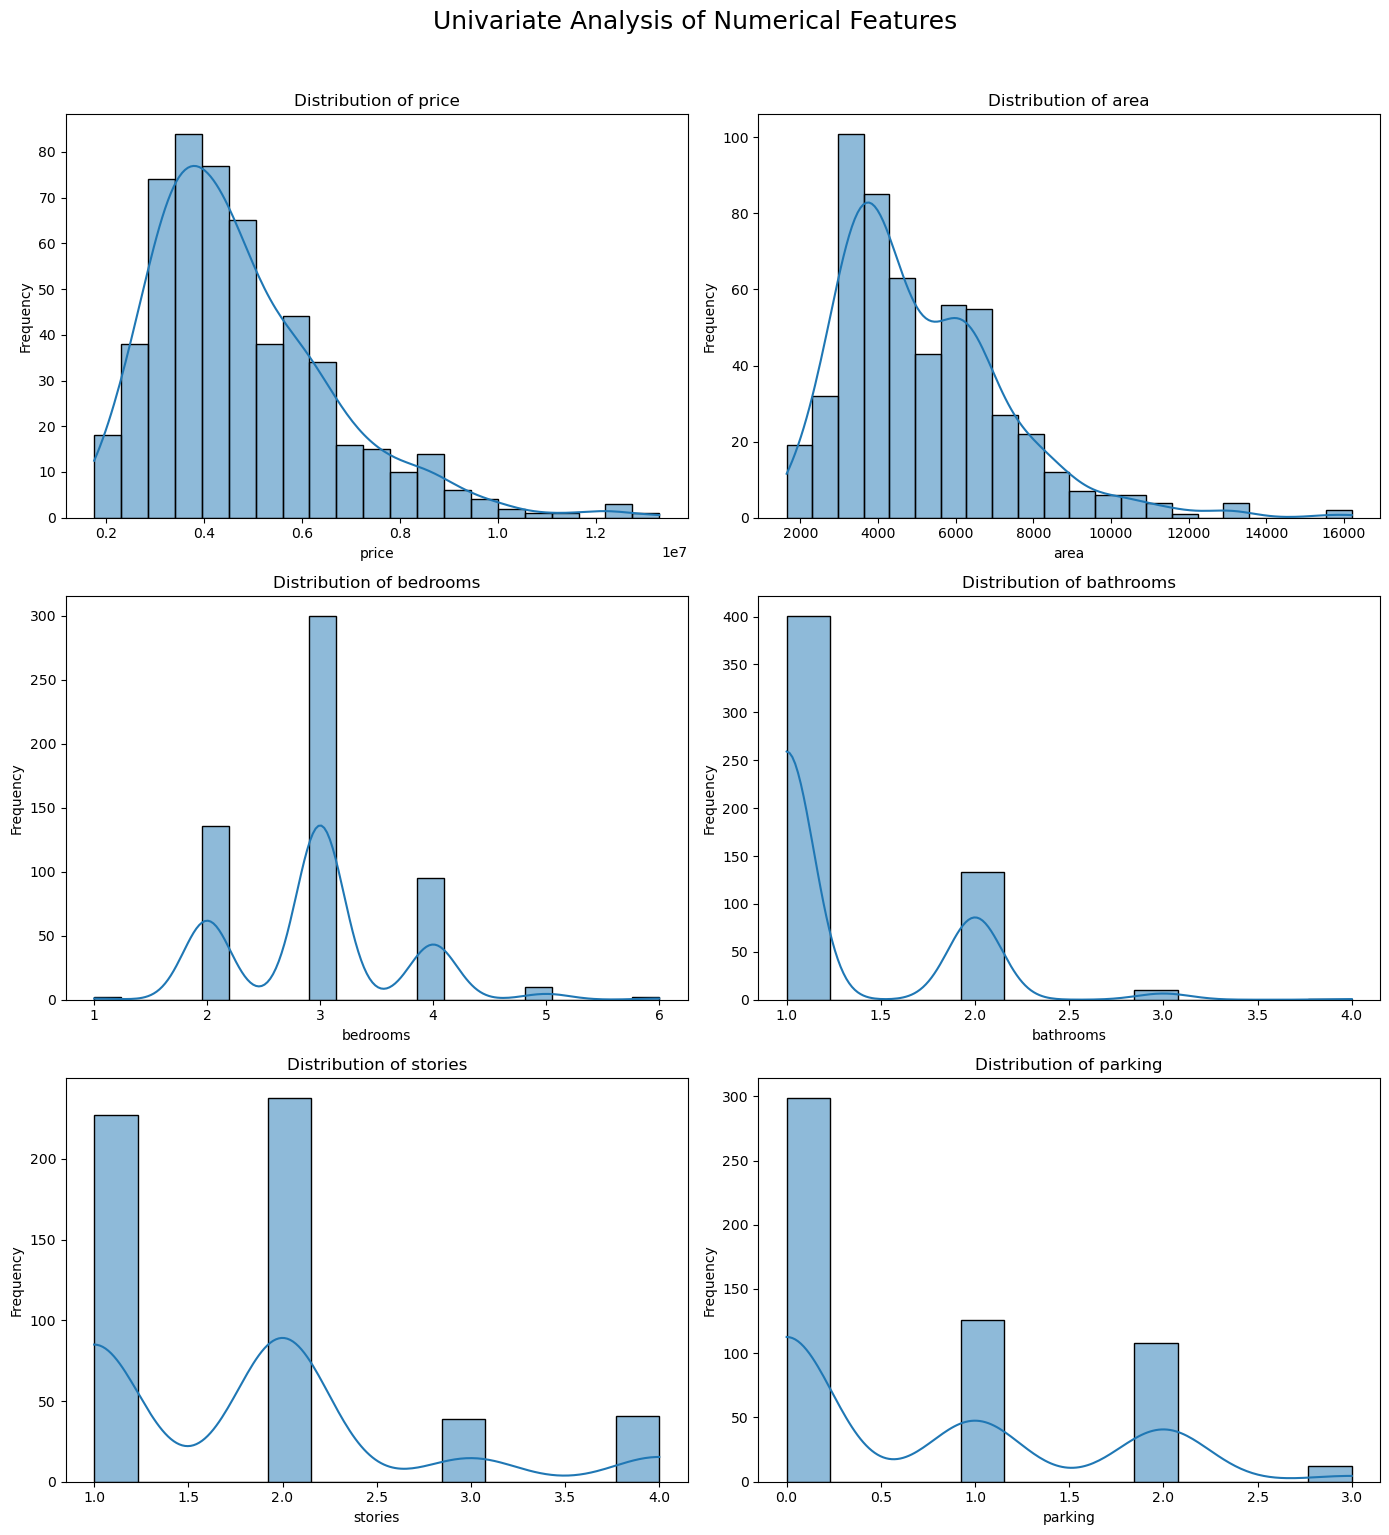

In [14]:
# My Step 12, Ploting Numerical Features
numeric_columns = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for ax, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Univariate Analysis of Numerical Features",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


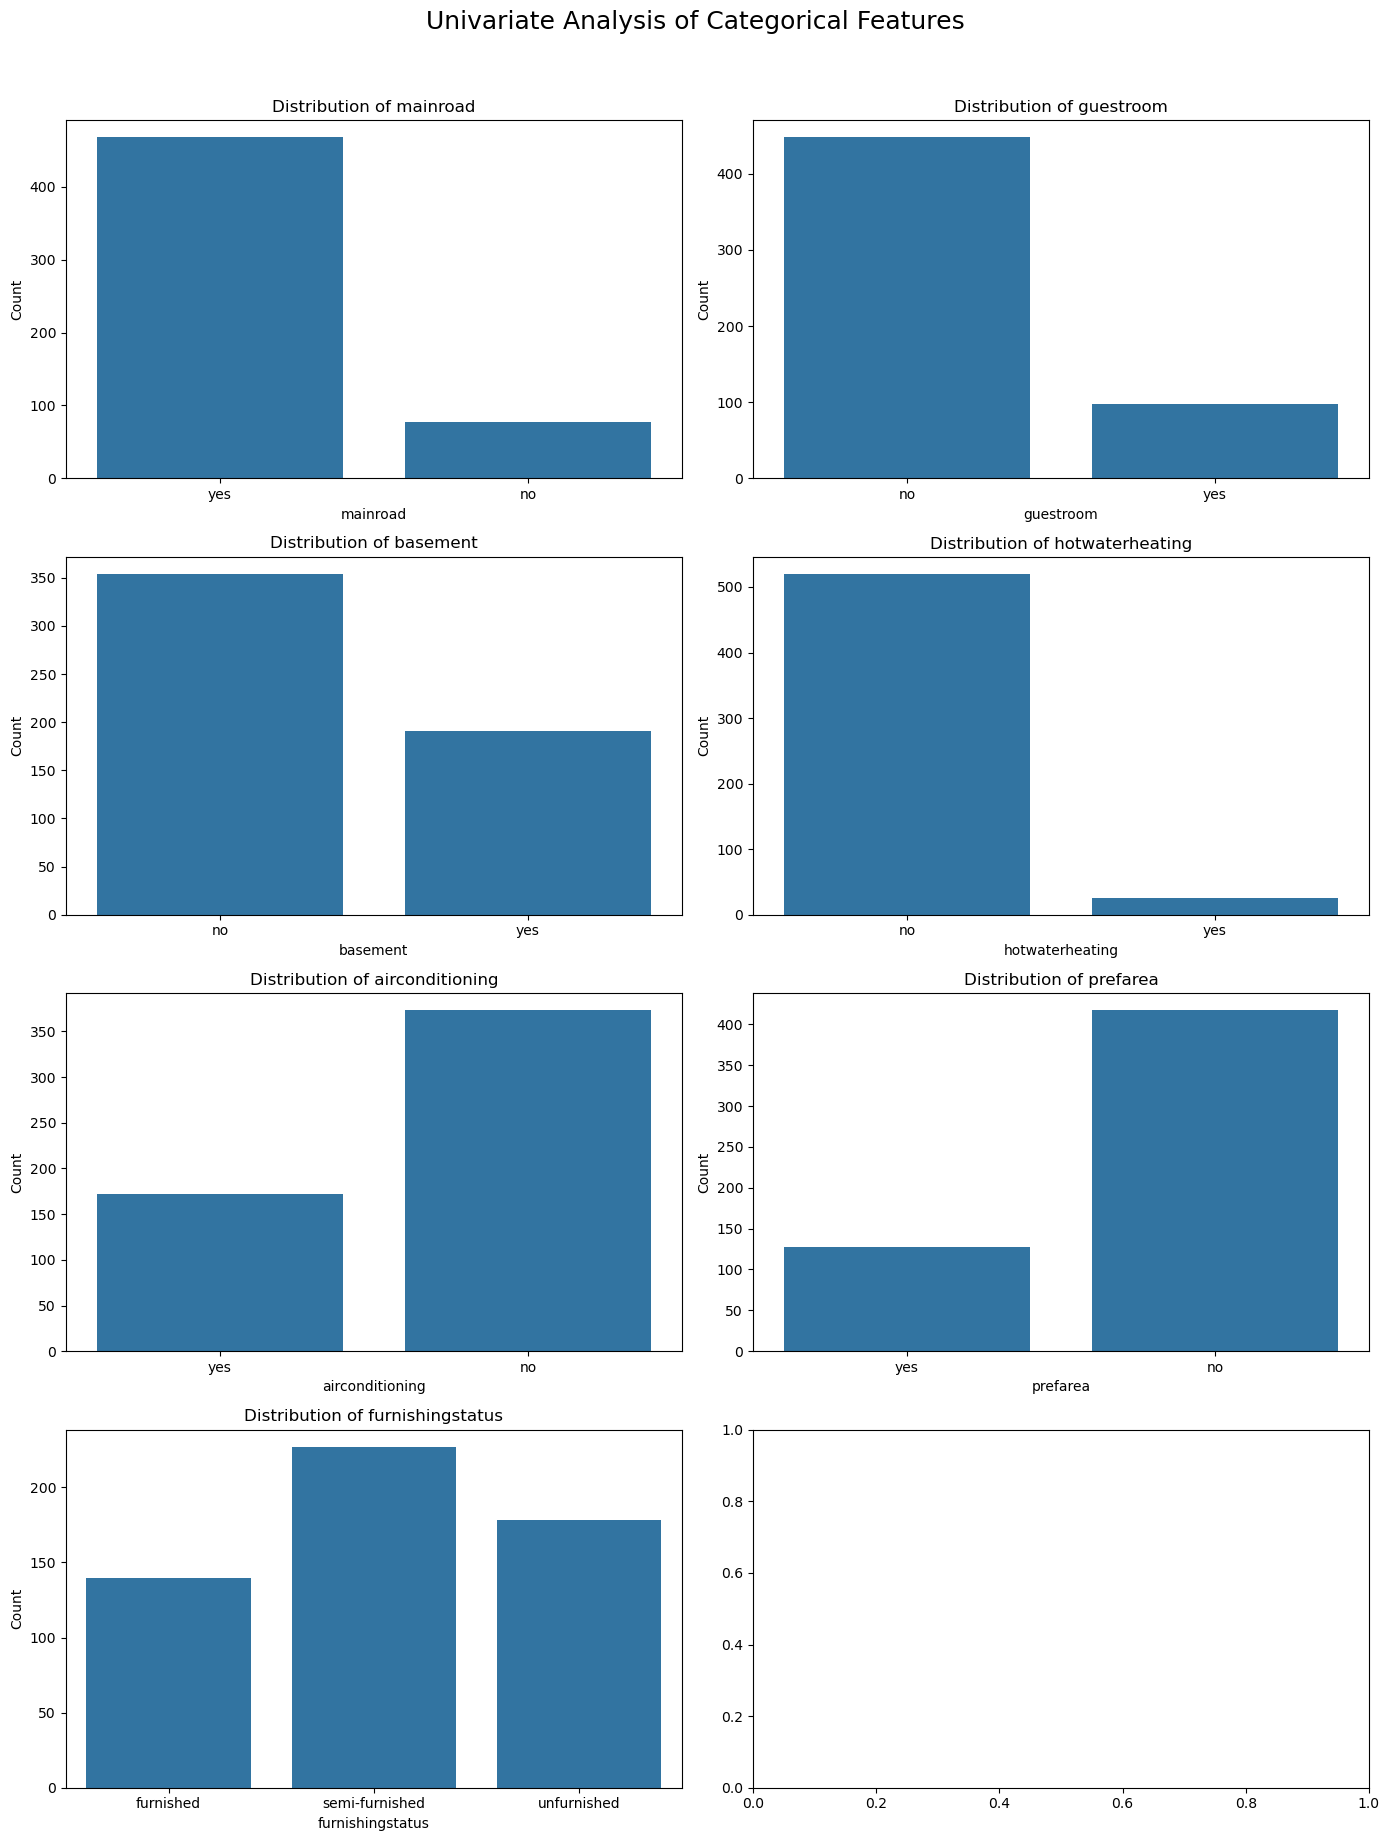

In [15]:
# My Step 13, ploting Categorical Variable

categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for ax, column in zip(axes.flatten(), categorical_columns):

    sns.countplot(
        data=df,
        x=column,
        ax=ax
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.suptitle(
    "Univariate Analysis of Categorical Features",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

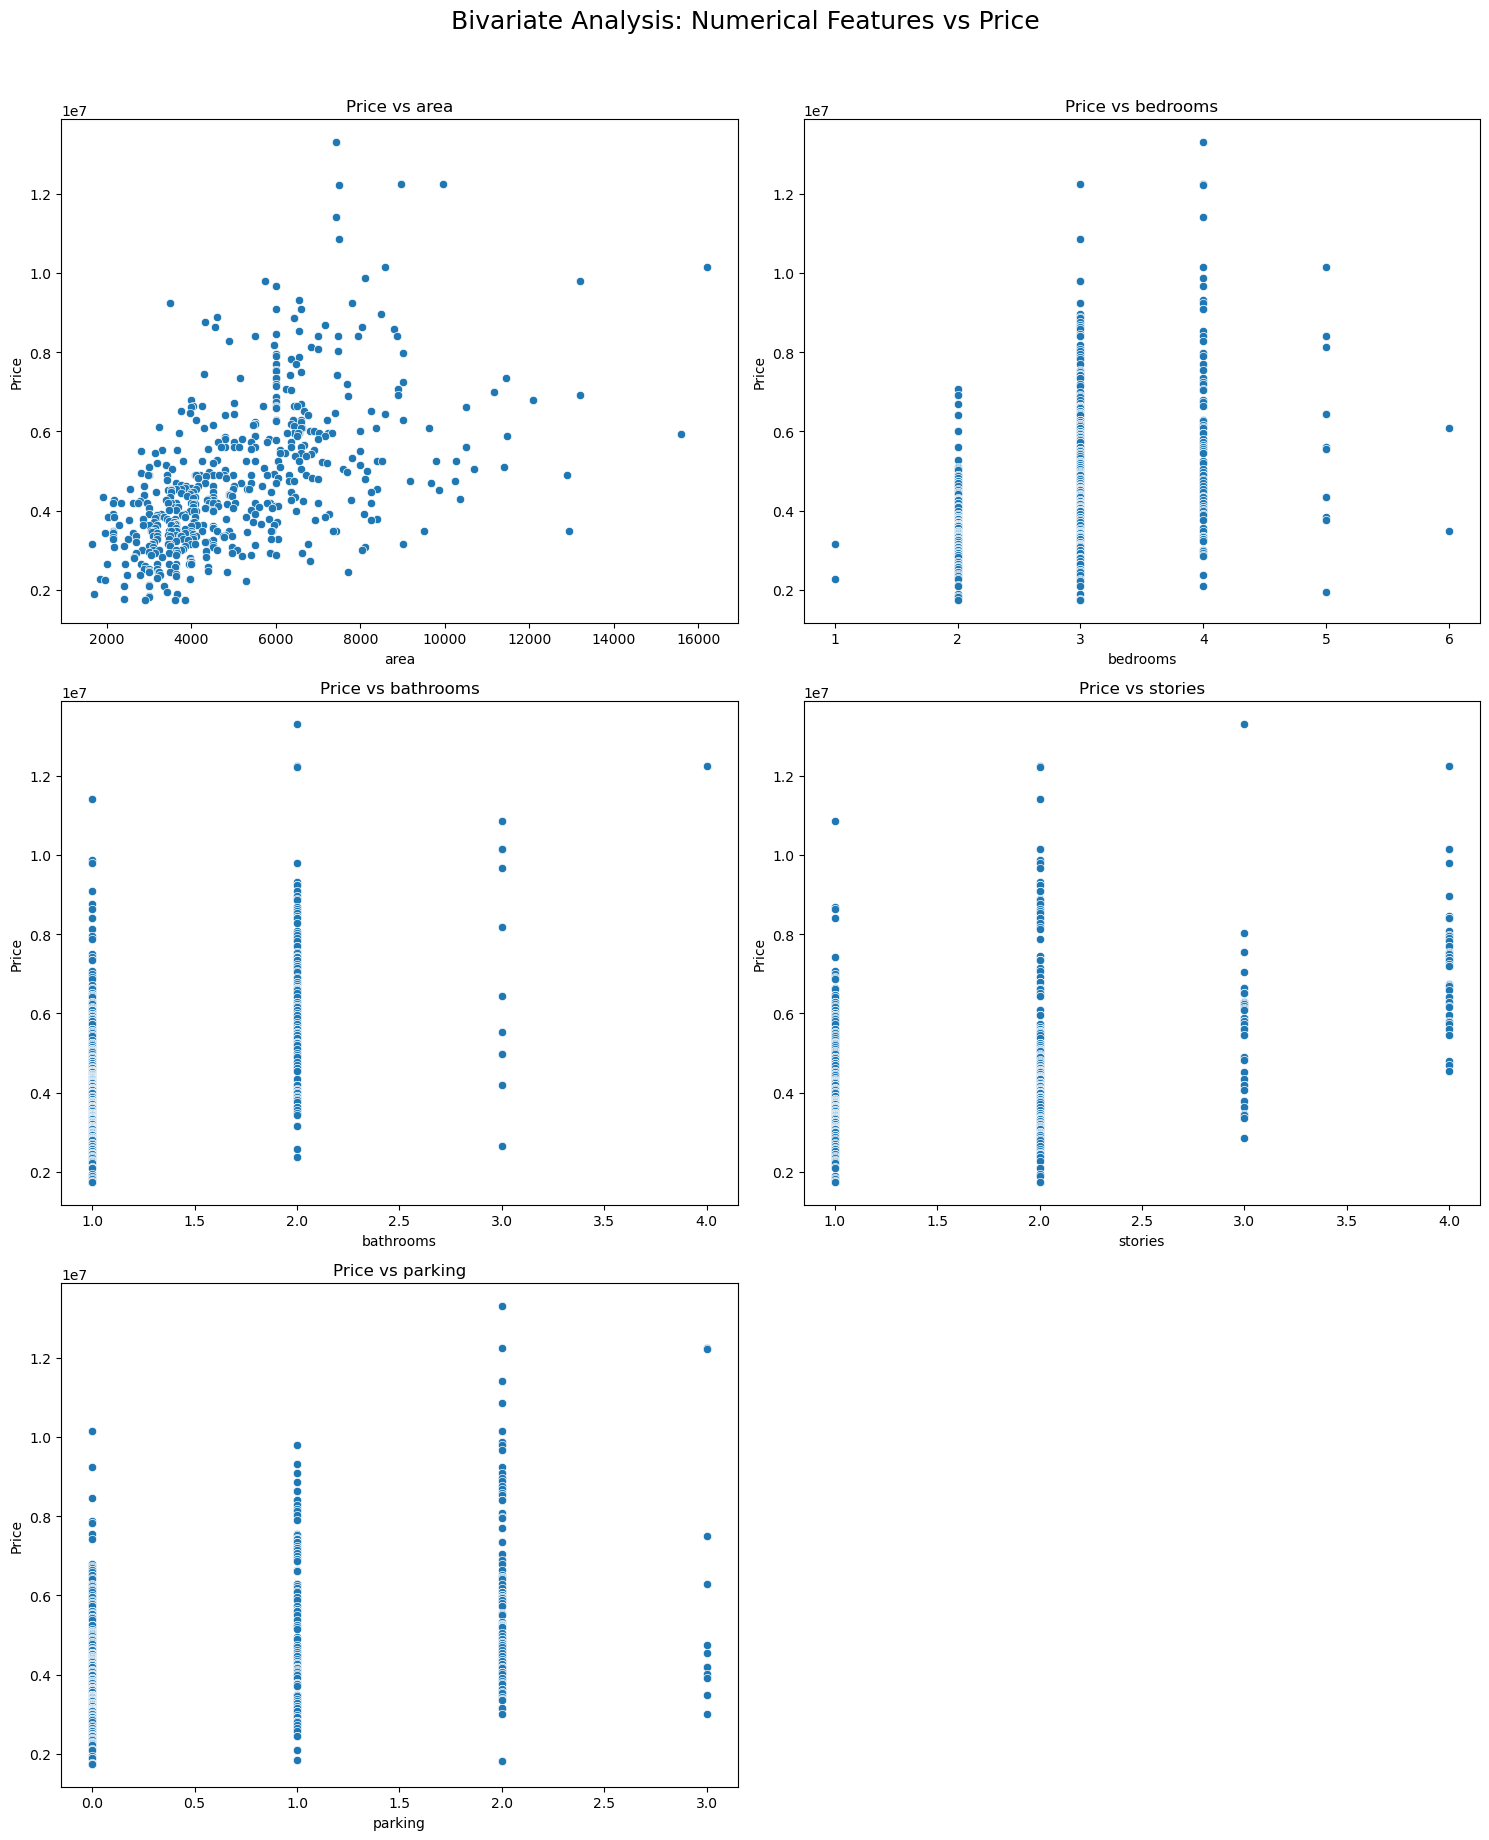

In [16]:
# Step 13, Bivariate Analysis of Num_Col

numeric_features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

for ax, feature in zip(axes.flatten(), numeric_features):

    sns.scatterplot(
        data=df,
        x=feature,
        y="price",
        ax=ax
    )

    ax.set_title(f"Price vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price")

# Hide unused subplot
axes.flatten()[-1].set_visible(False)

plt.suptitle(
    "Bivariate Analysis: Numerical Features vs Price",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

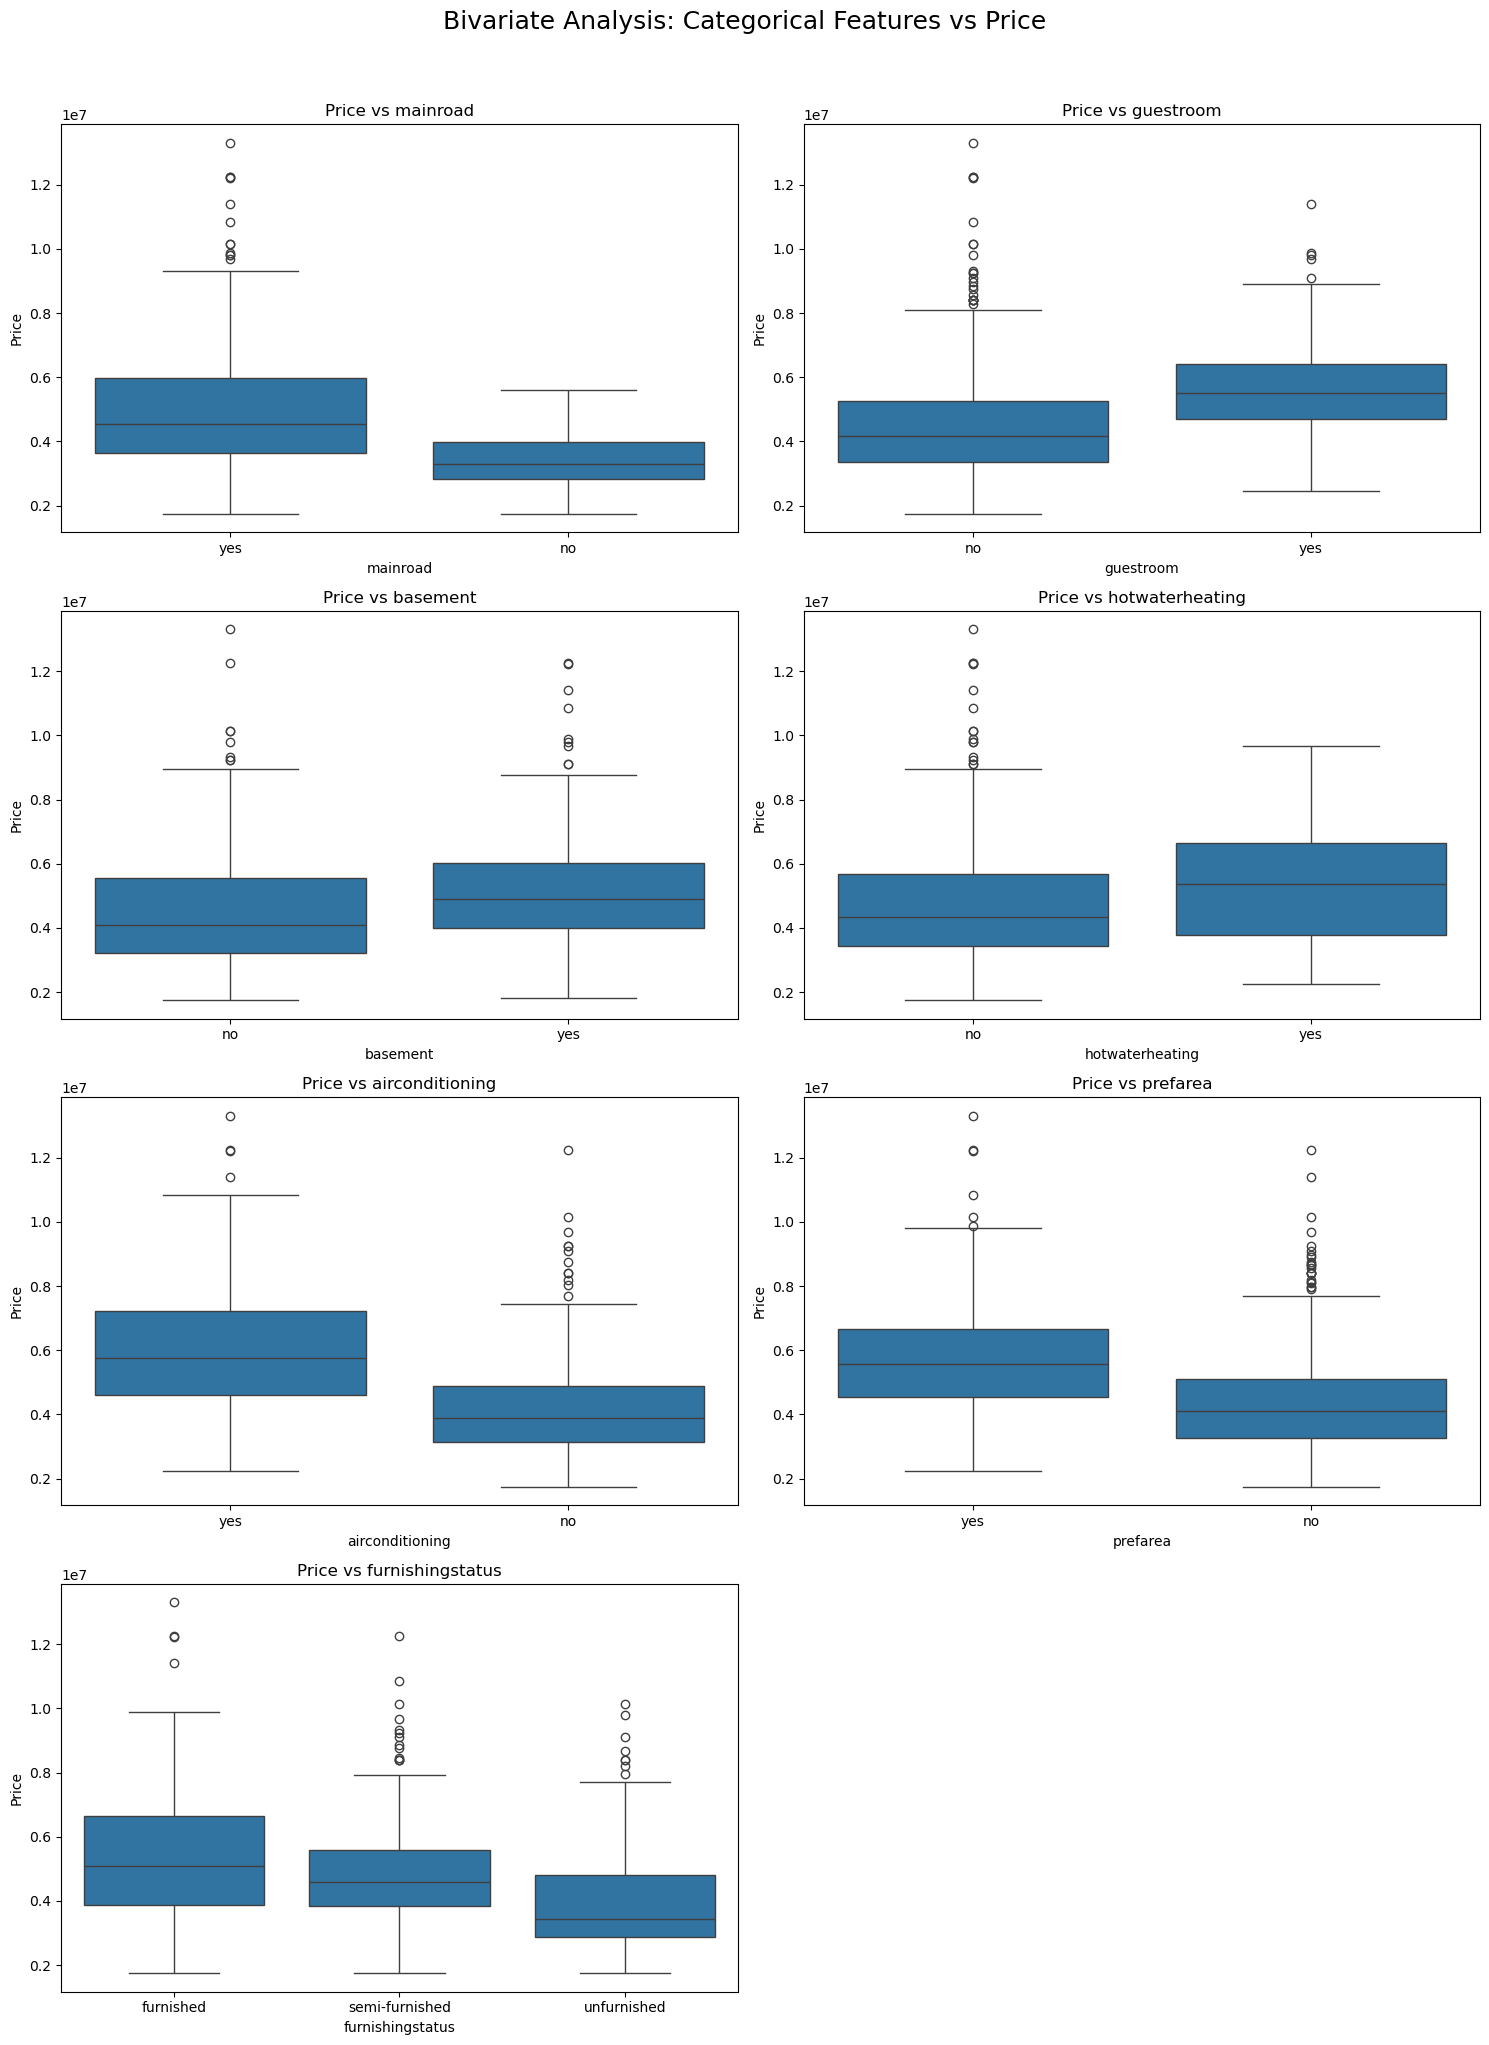

In [17]:
# Step 14, Bivariate Analysis of Cat_Col

categorical_features = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for ax, feature in zip(axes.flatten(), categorical_features):

    sns.boxplot(
        data=df,
        x=feature,
        y="price",
        ax=ax
    )

    ax.set_title(f"Price vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price")

axes.flatten()[-1].set_visible(False)

plt.suptitle(
    "Bivariate Analysis: Categorical Features vs Price",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


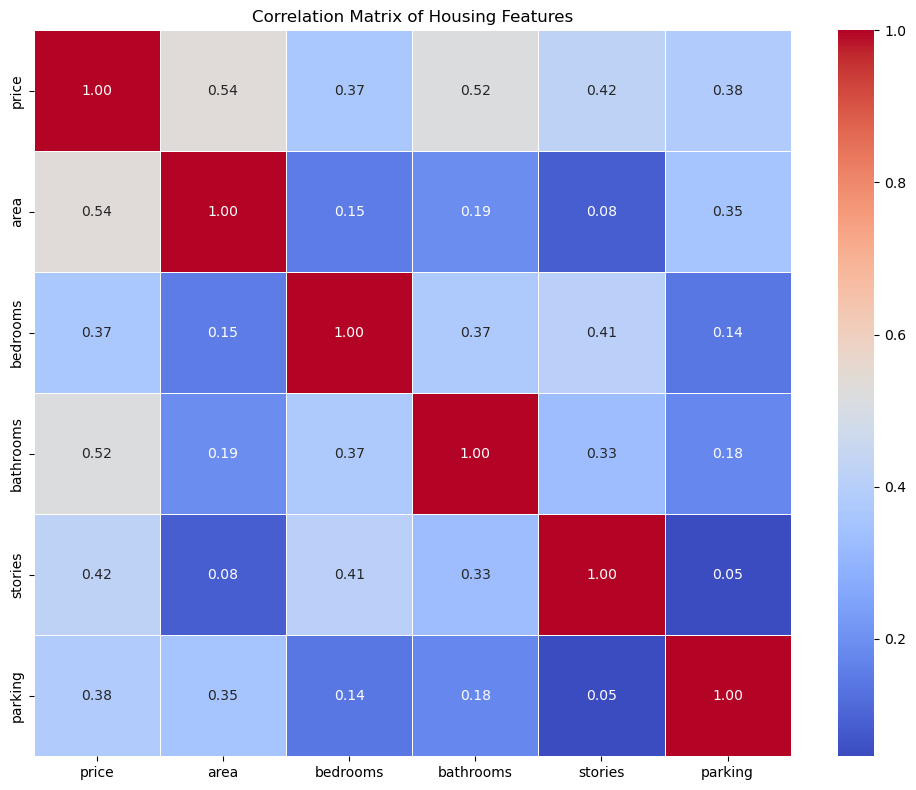

In [18]:
# Correlation Analysis. Step(15)
correlation_matrix = df[
    ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
].corr()

print(correlation_matrix)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Housing Features")
plt.tight_layout()
plt.show()

In [19]:
# Step 16

price_correlations = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

print(price_correlations)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


In [20]:
# Step 17

categorical_features = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

for column in categorical_features:
    print(f"\n{column}")
    print(
        df.groupby(column)["price"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )


mainroad
          count          mean     median
mainroad                                
yes         468  4.991777e+06  4550000.0
no           77  3.398905e+06  3290000.0

guestroom
           count          mean     median
guestroom                                
yes           97  5.792897e+06  5495000.0
no           448  4.544546e+06  4165000.0

basement
          count          mean     median
basement                                
yes         191  5.242615e+06  4900000.0
no          354  4.509966e+06  4077500.0

hotwaterheating
                 count          mean     median
hotwaterheating                                
yes                 25  5.559960e+06  5383000.0
no                 520  4.728593e+06  4329500.0

airconditioning
                 count          mean     median
airconditioning                                
yes                172  6.013221e+06  5757500.0
no                 373  4.191940e+06  3885000.0

prefarea
          count          mean     median
pref

In [ ]:
# Step 18
# Feature Seelction
X = df.drop("price", axis=1)
y = df["price"]